# Player matches

**Source:** `assets/playersmatches_test.csv` (46 MB, ~96k rows)

I worked through this the way I'd work a real ticket: look before deciding, write down what I believe
and why, and keep every assumption visible. So this notebook
follows the order I actually explored in, each section opens with the question I was trying to
answer and closes with what I concluded.

The questions I was given:

1. What is this dataset about? What is the scope?
2. How would I assess data quality? Any anomaly or outlier I can detect?
3. Compute all players' win/lose and K/D ratio distributions.
4. Compute max defeat and victory streaks, for players with at least 3 matches.
5. Compute other player features I think are relevant, and keep them all in one dataframe.
6. To train an ML model predicting player churn: how would I train and split the dataset, and which
   basic models would I test?

**To re-run this:** `pip install -r requirements.txt`, then run from the repository root (the data
path below is relative). Outputs land in `outputs/`.

In [49]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

DATA_PATH = Path("assets/playersmatches_test.csv")
OUTPUT_DIR = Path("outputs")
OUTPUT_DIR.mkdir(exist_ok=True)
assert DATA_PATH.exists(), f"Run this notebook from the repo root; {DATA_PATH} not found."

pd.set_option("display.width", 120)
pd.set_option("display.max_columns", 50)

# One palette for the whole notebook, so a colour always means the same thing.
BLUE, ORANGE, GREEN, VERMILLION, GREY = "#0072B2", "#E69F00", "#009E73", "#D55E00", "#6E6E6E"
ACTIVE_C, CHURNED_C = BLUE, ORANGE  # active = blue, churned = orange, everywhere

plt.rcParams.update({
    "figure.dpi": 110,
    "figure.facecolor": "white",
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.25,
    "grid.linewidth": 0.6,
    "axes.titlesize": 11,
    "axes.titleweight": "bold",
    "axes.labelsize": 9,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "legend.frameon": False,
    "legend.fontsize": 8,
})

---
## 1. First look, what does the data looks like

Before any aggregation I want three things: the column types, what one row represents, and
whether the file is as rectangular as it looks.

In [50]:
df = pd.read_csv(DATA_PATH)
print(f"{df.shape[0]:,} rows x {df.shape[1]} columns\n")
print(df.dtypes.to_string())
df.head(3)

95,734 rows x 11 columns

playerid                 str
matchid                  str
gamemode                 str
victory                  str
kills                float64
death                float64
match_datetime           str
playernb_in_match      int64
still_active            bool
teammateid               str
opponentid               str


,playerid,matchid,gamemode,victory,kills,death,match_datetime,playernb_in_match,still_active,teammateid,opponentid
0,00f2d75c-7aeb-465b-8d82-7085837cade3,7c5bf406-e736-4faf-9ad3-d0212ecef357,PVP,false,0.0,3.0,2025-06-11T05:45:08.995Z,11,True,"367d1918-35a1-44bc-ae39-88978561ac82,3f058b2c-...","2fd83c37-e6bd-409a-8b43-5363c3c8dd46,306ab552-..."
1,10c31731-4ea8-477b-bcf3-8b3424f956e9,006fd414-9d56-4c5c-bec4-1e177f4012d3,PVP,false,4.0,3.0,2025-09-24T13:23:27.592Z,10,False,"52476f97-0543-4972-b0c4-a04f4ecb5d11,70678777-...","3db5b6de-7df1-437b-86f2-6d87926f5260,9fb7969b-..."
2,10c31731-4ea8-477b-bcf3-8b3424f956e9,0199977b-f28e-4518-a20b-6b3bbb4a3abf,PVP,true,6.0,4.0,2025-09-24T13:36:40.815Z,11,False,"425463e6-cb7f-4228-8ae8-2089550d7e1a,707864ee-...","2a328963-a705-46bc-8111-df7f9a3eb090,3ba1c18e-..."


Two things already stand out from the dtypes:

- `kills` and `death` came in as float, not int. pandas read the literal string `null` as a
  missing value. So there are holes in the per-match stats.
- `victory` came in as string, not bool. If it only held `true`/`false`, pandas would have made
  it a boolean. So it contains something else too, which I need to look at.

`still_active` did parse as a clean boolean. Now lets get the timestamps into a real datetime and
derive the few calendar helpers I'll reuse.

In [51]:
ORIGINAL_COLUMNS = list(df.columns)   # so the checks in section 2 only audit source columns

df["match_ts"] = pd.to_datetime(df["match_datetime"], format="ISO8601", utc=True)
df["match_date"] = df["match_ts"].dt.date
df["is_weekend"] = df["match_ts"].dt.dayofweek >= 5
df["is_evening"] = df["match_ts"].dt.hour.between(18, 23)   # UTC hours - caveat in section 2.6

# Numeric 1/0 for wins, so that NaN means "not a decided match" (see section 2.2).
df["is_win"] = df["victory"].map({"true": 1.0, "false": 0.0})
df["churned"] = ~df["still_active"]

print("first match:", df["match_ts"].min())
print("last match :", df["match_ts"].max())
print("span       :", (df["match_ts"].max() - df["match_ts"].min()).days, "days")

first match: 2025-03-04 15:04:17.034000+00:00
last match : 2026-03-03 13:54:20.190000+00:00
span       : 363 days


### What is one row?

Lets explore the rows more with some interisting inisghts

In [52]:
grain = pd.Series({
    "rows": len(df),
    "distinct playerid": df["playerid"].nunique(),
    "distinct matchid": df["matchid"].nunique(),
    "duplicated (playerid, matchid) pairs": df.duplicated(["playerid", "matchid"]).sum(),
    "fully duplicated rows": df.duplicated().sum(),
    "matchid appearing more than once": (df["matchid"].value_counts() > 1).sum(),
})
grain.to_frame("value")

,value
rows,95734
distinct playerid,840
distinct matchid,95723
"duplicated (playerid, matchid) pairs",0
fully duplicated rows,0
matchid appearing more than once,11


No duplicated `(playerid, matchid)` pair, no duplicated row. But the interesting
number is the **95,723 distinct `matchid` for 95,734 rows** -> a match almost never
appears twice.

If this were full match telemetry, each match would appear 10 times (as in r6s matches are 5v5). 
Instead I have **840 players**, each of their matches
recorded once. So this is a *player-centric sample*: a cohort of 840 players, with the other
participants only referenced by id in `teammateid` / `opponentid`.

I can test that directly, how many of those referenced ids belong to my 840?

In [53]:
def roster_ids(series: pd.Series) -> pd.Series:
    # Explode a comma-separated id column into one id per row, dropping blanks.
    exploded = series.fillna("").str.split(",").explode()
    return exploded[(exploded != "") & (exploded != "null")]

teammates = roster_ids(df["teammateid"])
opponents = roster_ids(df["opponentid"])
referenced = pd.concat([teammates, opponents])

cohort = set(df["playerid"])
referenced_unique = set(referenced.unique())

print(f"roster slots filled              : {len(referenced):,}")
print(f"distinct players referenced      : {len(referenced_unique):,}")
print(f"...of which are in our 840 cohort: {len(referenced_unique & cohort)}")

roster slots filled              : 908,600
distinct players referenced      : 710,282
...of which are in our 840 cohort: 21


**This is the single most important scope fact in the dataset.** The 840 tracked players met
~710,000 *distinct* other players, and only **21** of those are themselves in the cohort.

So the 840 are a thin sample out of a player base of at least several hundred thousand.

### Scope: period, modes, match sizes, and the label

In [54]:
print("== Game modes ==")
print(df["gamemode"].value_counts().to_frame("matches").assign(
    share_pct=lambda d: (d["matches"] / len(df) * 100).round(2)).to_string(), "\n")

print("== Players per match ==")
print(df["playernb_in_match"].describe().round(2).to_string(), "\n")

print("== Matches per player ==")
matches_per_player = df.groupby("playerid").size()
print(matches_per_player.describe().round(1).to_string(), "\n")

print("== still_active (the churn label) ==")
label = df.groupby("playerid")["still_active"].first()
print(label.value_counts().to_frame("players").assign(
    share_pct=lambda d: (d["players"] / len(label) * 100).round(1)).to_string())

== Game modes ==
              matches  share_pct
gamemode                        
PVP_RANKED      48563      50.73
PVP             32267      33.70
PVP_UNRANKED    14899      15.56
OPERATIONS          5       0.01 

== Players per match ==
count    95734.00
mean        10.49
std          1.29
min          1.00
25%         10.00
50%         10.00
75%         10.00
max         25.00 

== Matches per player ==
count     840.0
mean      114.0
std       214.3
min         1.0
25%         5.0
50%        27.5
75%       111.2
max      1974.0 

== still_active (the churn label) ==
              players  share_pct
still_active                    
False             488       58.1
True              352       41.9


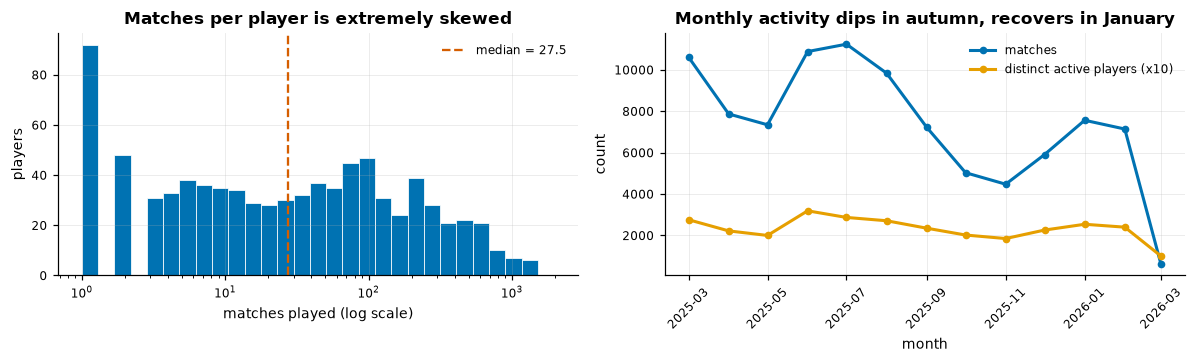

,matches,players,matches_per_active_player
match_ts,,,
2025-03-01 00:00:00+00:00,10617,276,38.5
2025-04-01 00:00:00+00:00,7869,222,35.4
2025-05-01 00:00:00+00:00,7346,200,36.7
2025-06-01 00:00:00+00:00,10884,319,34.1
2025-07-01 00:00:00+00:00,11240,287,39.2
2025-08-01 00:00:00+00:00,9839,271,36.3
2025-09-01 00:00:00+00:00,7223,235,30.7
2025-10-01 00:00:00+00:00,5031,202,24.9
2025-11-01 00:00:00+00:00,4475,185,24.2


In [55]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.4))

# Left: how much activity each player contributes. Log x, because the spread is huge.
bins = np.logspace(0, np.log10(matches_per_player.max()), 30)
axes[0].hist(matches_per_player, bins=bins, color=BLUE, edgecolor="white", linewidth=0.5)
axes[0].set_xscale("log")
axes[0].axvline(matches_per_player.median(), color=VERMILLION, linestyle="--", linewidth=1.5,
                label=f"median = {matches_per_player.median():.1f}")
axes[0].set(title="Matches per player is extremely skewed",
            xlabel="matches played (log scale)", ylabel="players")
axes[0].legend()

# Right: volume over time, to check the window is evenly covered.
monthly = df.resample("MS", on="match_ts").agg(
    matches=("matchid", "size"), players=("playerid", "nunique"))
axes[1].plot(monthly.index, monthly["matches"], color=BLUE, linewidth=2, marker="o", markersize=4,
             label="matches")
axes[1].plot(monthly.index, monthly["players"] * 10, color=ORANGE, linewidth=2, marker="o",
             markersize=4, label="distinct active players (x10)")
axes[1].set(title="Monthly activity dips in autumn, recovers in January", xlabel="month",
            ylabel="count")
axes[1].legend()
axes[1].tick_params(axis="x", rotation=45)

fig.tight_layout()
plt.show()

monthly.assign(matches_per_active_player=lambda d: (d["matches"] / d["players"]).round(1))

I rescaled the active-player line by 10 to put it on the same axis as match volume. I deliberately
avoid a second y-axis, because two independent scales on one chart make the crossing points look
meaningful when they aren't.

#### Interpretation of the plots :

I expected a steady decline here, given a 58% churn label, and that is *not* what the data shows.
Match volume peaks in July (11.2k), troughs in November (4.5k) and recovers to 7.6k in January; the
monthly count of distinct active players drifts only mildly, 276 in March to 240 in February, with a
dip to 185 in November. (March 2026 is 3 days long, so ignore the last point.) That shape reads as
seasonality — an autumn lull and a new-year return — not a collapsing player base.

What *does* decline monotonically is intensity: matches per active player falls from ~38 to ~30
(−23%) across the year. So the surviving players are playing somewhat less, while the cohort shrinks
slowly. Churn in this dataset is therefore spread across the whole year rather than concentrated in
one cliff — which matters in section 6, because it means a single cutoff date can't cleanly separate
"before" from "after".

### Answers to questions 1 and 2 (what / scope)

**What it is.** A player-match history : one row per player per
match, holding the player's outcome (`victory`), combat stats (`kills`, `death`), match context
(`gamemode`, `playernb_in_match`, `match_datetime`), the anonymised rosters (`teammateid`,
`opponentid`), and one player-level attribute, `still_active`, which is the churn label the dataset
is built around.

**Scope.**

| Dimension | Value |
|---|---|
| Rows (player-match participations) | 95,734 |
| Tracked players (cohort) | 840 |
| Other players referenced | ~710k distinct (only 21 in the cohort) |
| Period | 2025-03-04 → 2026-03-03 (363 days) |
| Modes | `PVP_RANKED` 50.7%, `PVP` 33.7%, `PVP_UNRANKED` 15.6%, `OPERATIONS` 5 rows |
| Typical match size | 10 players (73% of rows), range 1–25 |
| Activity per player | median 27.5 matches, mean 114, max 1,974 |
| Label | 488 churned / 352 active = **58.1% churn** |

---
## 2. Data quality

I'd rather not print `isna().sum()` and call that an assessment. I'll go dimension by dimension 
(completeness, validity, consistency, uniqueness, plausibility, timeliness) because each one needs a
different kind of check, and because that's the structure I'd reuse to write a data contract.

### 2.1 Completeness

In [56]:
source = df[ORIGINAL_COLUMNS]
missing = pd.DataFrame({
    "missing": source.isna().sum(),
    "missing_pct": (source.isna().mean() * 100).round(3),
})
print(missing[missing["missing"] > 0].to_string(), "\n")

stats_missing = df["kills"].isna()
print(f"rows where kills AND death are both missing: {(stats_missing & df['death'].isna()).sum()}")
print("\nthose rows still carry an outcome:", df.loc[stats_missing, "victory"].value_counts().to_dict())
print("spread across modes:", df.loc[stats_missing, "gamemode"].value_counts().to_dict())

# Where are the empty roster columns? An empty roster is only legitimate for a solo match.
print("\nrows with an empty roster column:")
print(df.loc[df["teammateid"].isna() | df["opponentid"].isna()]
      .assign(missing_teammates=lambda d: d["teammateid"].isna(),
              missing_opponents=lambda d: d["opponentid"].isna())
      .groupby(["gamemode", "playernb_in_match"])[["missing_teammates", "missing_opponents"]]
      .sum().to_string())

            missing  missing_pct
kills           153        0.160
death           153        0.160
teammateid        6        0.006
opponentid       11        0.011 

rows where kills AND death are both missing: 153

those rows still carry an outcome: {'true': 78, 'false': 75}
spread across modes: {'PVP_RANKED': 80, 'PVP': 46, 'PVP_UNRANKED': 27}

rows with an empty roster column:
                                missing_teammates  missing_opponents
gamemode     playernb_in_match                                      
OPERATIONS   1                                  5                  5
PVP          5                                  0                  4
PVP_RANKED   5                                  0                  1
PVP_UNRANKED 1                                  1                  1


Completeness is good in volume (0.16% of rows) but the *pattern* is the useful part.

- The 153 missing `kills` and 153 missing `death` are **the same 153 rows**: the combat block goes
  missing as a unit, not value by value. That reads like a telemetry/ingestion drop rather than a
  gameplay situation, and it's spread across modes and across both outcomes, so it's plausibly
  missing-at-random rather than hiding one specific case.
- The missing `teammateid` (6) sit on exactly the 6 rows where `playernb_in_match = 1`, so an empty
  roster is the *correct* value there.

**Decision:** I will *not* fill the missing kills/death with 0. Coercing them would drag those
players' K/D down for a reason that has nothing to do with how they played. I exclude those 153 rows
from kill/death aggregation and keep them everywhere else, the outcome is still valid, so they
still count towards win rate and streaks.

### 2.2 Validity (do the values match the types they claim?)

This is where the `victory` column surprised me, as a r6s player i am not sure its possible to have a draw.

In [57]:
print("victory values:")
print(df["victory"].value_counts().to_frame("rows").assign(
    share_pct=lambda d: (d["rows"] / len(df) * 100).round(3)).to_string(), "\n")

odd_outcomes = df["victory"].isin(["draw", "other"])
print("where the non-boolean outcomes occur:")
print(pd.crosstab(df.loc[odd_outcomes, "victory"], df.loc[odd_outcomes, "gamemode"]).to_string())

victory values:
          rows  share_pct
victory                  
false    49761     51.978
true     45917     47.963
draw        43      0.045
other       13      0.014 

where the non-boolean outcomes occur:
gamemode  OPERATIONS  PVP  PVP_RANKED  PVP_UNRANKED
victory                                            
draw               0    8          27             8
other              2    6           4             1


`victory` is **not** boolean: alongside `true` (45,917) and `false` (49,761) there are **43 `draw`**
and **13 `other`**. Tiny (0.06% of rows) but it's exactly the kind of thing that silently corrupts
a metric: `df['victory'] == 'true'` quietly buckets draws as defeats, and anyone computing
"losses = total − wins" is wrong by 56 rows.

`draw` only ever appears in PvP modes, which is normally not possible in game. `other` shows
up in PvP *and* in 2 of the 5 `OPERATIONS` rows, which suggests a catch-all for aborted or
undetermined matches.

**Decision, stated once and applied everywhere below:** `draw` and `other` are *not* defeats. I
exclude them from the win-rate denominator (win rate = wins / decided matches), but i will assume that a draw can be possible and let them
**break** both victory and defeat streaks, because a draw is neither a win nor a loss.

### 2.3 Consistency (do the columns agree with each other?)

`still_active` is stored on every row of a player-match table, so the first thing to verify is that
it's constant per player. Then I check the
rosters against `playernb_in_match`.

In [58]:
flags_per_player = df.groupby("playerid")["still_active"].nunique()
print(f"players whose still_active is not constant: {(flags_per_player > 1).sum()} / {len(flags_per_player)}")


def count_ids(series: pd.Series) -> pd.Series:
    # Vectorised count of comma-separated ids; blank/"null" -> 0.
    cleaned = series.fillna("").replace("null", "")
    return cleaned.str.count(",").add(1).where(cleaned != "", 0).astype(int)


n_teammates = count_ids(df["teammateid"])
n_opponents = count_ids(df["opponentid"])

roster_total = 1 + n_teammates + n_opponents
print(f"rows where 1 + teammates + opponents != playernb_in_match: "
      f"{(roster_total != df['playernb_in_match']).sum()}")

full_roster = df["teammateid"].fillna("") + "," + df["opponentid"].fillna("")
self_listed = sum(pid in roster for pid, roster in zip(df["playerid"], full_roster))
print(f"rows where the player appears in their own roster       : {self_listed}")

players whose still_active is not constant: 0 / 840
rows where 1 + teammates + opponents != playernb_in_match: 0
rows where the player appears in their own roster       : 0


In [59]:
# Team balance: own team (player + teammates) vs the opposing team.
balance = pd.DataFrame({"own_team": n_teammates + 1, "opposing_team": n_opponents})
print("most common team-size combinations:")
print(balance.value_counts().head(8).to_frame("rows").to_string(), "\n")
print(f"share of matches with balanced teams: "
      f"{(balance['own_team'] == balance['opposing_team']).mean():.1%}")

most common team-size combinations:
                         rows
own_team opposing_team       
5        5              70000
6        5               4372
5        6               3725
7        5               2266
5        4               2046
6        6               1802
5        7               1667
4        5               1610 

share of matches with balanced teams: 75.6%


Good news first. `still_active` is **perfectly constant** per player (0 of 840 inconsistent), so it
is genuinely a player attribute and a usable label. The roster arithmetic is also internally perfect:
`1 + teammates + opponents == playernb_in_match` on every single row, and no player ever appears in
their own roster. Whoever generated this file was consistent about it.

The anomaly is in the *balance*: only **75.6%** of matches have equal-sized teams. The rest are
6-v-5, 5-v-6, 7-v-5, even 8-v-5. Some of that is realistic (disconnects mid-match in a 5-v-5 title),
but 7-v-5 is not possible in any of r6s modes. I flag it rather than fix it, and I avoid building any
feature that assumes a clean 5-v-5.

### 2.4 Uniqueness and referential integrity

11 `matchid` values appear twice, which means two cohort players were in the same match. In this
dataset that's a rare gift: the only place where I can **cross-check the file against itself**. If
player A and player B were in the same match, A's roster should mention B, and their outcomes should
be compatible.

In [60]:
shared_ids = df["matchid"].value_counts().loc[lambda s: s > 1].index
checks = []

for match_id, pair in df[df["matchid"].isin(shared_ids)].groupby("matchid"):
    a, b = pair.iloc[0], pair.iloc[1]

    def relation(seen_by, other):
        mates = seen_by["teammateid"] if isinstance(seen_by["teammateid"], str) else ""
        foes = seen_by["opponentid"] if isinstance(seen_by["opponentid"], str) else ""
        if other["playerid"] in mates:
            return "teammate"
        if other["playerid"] in foes:
            return "opponent"
        return "ABSENT"

    rel = relation(a, b)
    checks.append({
        "matchid": match_id[:8],
        "mode": a["gamemode"],
        "A_sees_B": rel,
        "B_sees_A": relation(b, a),
        "victory_A": a["victory"],
        "victory_B": b["victory"],
        # Opponents must disagree on the outcome; teammates must agree.
        "outcomes_coherent": (a["victory"] != b["victory"]) if rel == "opponent"
                             else (a["victory"] == b["victory"]),
        "timestamp_gap_s": round(abs((a["match_ts"] - b["match_ts"]).total_seconds()), 1),
    })

shared_check = pd.DataFrame(checks)
shared_check

,matchid,mode,A_sees_B,B_sees_A,victory_A,victory_B,outcomes_coherent,timestamp_gap_s
0,03080a9e,PVP,opponent,opponent,false,true,True,6.8
1,1767c1fb,PVP_RANKED,opponent,opponent,false,true,True,7.3
2,3339abe7,PVP,opponent,opponent,false,true,True,366.6
3,54753d54,PVP_RANKED,teammate,teammate,false,false,True,270.3
4,85421105,PVP,opponent,opponent,false,true,True,10.1
5,89eda808,PVP_RANKED,opponent,opponent,false,true,True,24.1
6,97b92696,PVP_RANKED,opponent,opponent,true,false,True,23.2
7,da011e60,PVP_UNRANKED,teammate,teammate,true,false,False,4.3
8,fcf4793c,PVP,teammate,teammate,false,false,True,5.6
9,fdb6d7b6,PVP_RANKED,opponent,opponent,false,true,True,0.3


Three findings from those 11 matches, and all three matter:

1. **Referential integrity holds.** Every pair sees each other, and symmetrically —> if A lists B as
   an opponent, B lists A as an opponent. No `ABSENT`, no disagreement about the relationship. The
   roster columns are trustworthy.
2. **One outcome contradiction.** Match `da011e60`: the two players are **teammates**, yet one has
   `victory=true` and the other `victory=false`. That is impossible. 10 of 11 are coherent (all 7
   opponent pairs disagree as they should, 3 of 4 teammate pairs agree), so the error rate is low
   but it is non-zero, and with only 11 observable cases I can't assume the other ~95,700 rows are
   cleaner than 1 in 11.
3. **`match_datetime` is not the match start time.** The two records of the *same* match differ by
   0.3 s to 366 s (small but not equal). So the timestamp is a per-player event time.
   Good enough to order a player's own matches chronologically, which is all I need for streaks and
   gaps, but I should not compare timestamps across players or use them to identify a match.

### 2.5 Plausibility and outliers

Now the distributions themselves. I'm looking for values that are *possible* in the schema but
implausible in the game.

In [61]:
print(df[["kills", "death", "playernb_in_match"]].describe().round(2).to_string(), "\n")
print("kills value counts (tail):")
print(df["kills"].value_counts().sort_index().tail(10).to_frame("rows").to_string(), "\n")
print("death value counts (full):")
print(df["death"].value_counts().sort_index().to_frame("rows").to_string())

          kills     death  playernb_in_match
count  95581.00  95581.00           95734.00
mean       3.53      3.59              10.49
std        2.79      1.81               1.29
min        0.00      0.00               1.00
25%        1.00      2.00              10.00
50%        3.00      4.00              10.00
75%        5.00      5.00              10.00
max       26.00      9.00              25.00 

kills value counts (tail):
       rows
kills      
14.0    157
15.0     71
16.0     42
17.0     25
18.0     12
19.0      3
20.0      4
21.0      1
25.0      1
26.0      1 

death value counts (full):
        rows
death       
0.0     4082
1.0     9041
2.0    12678
3.0    19145
4.0    23128
5.0    14545
6.0     7224
7.0     3732
8.0     1714
9.0      292


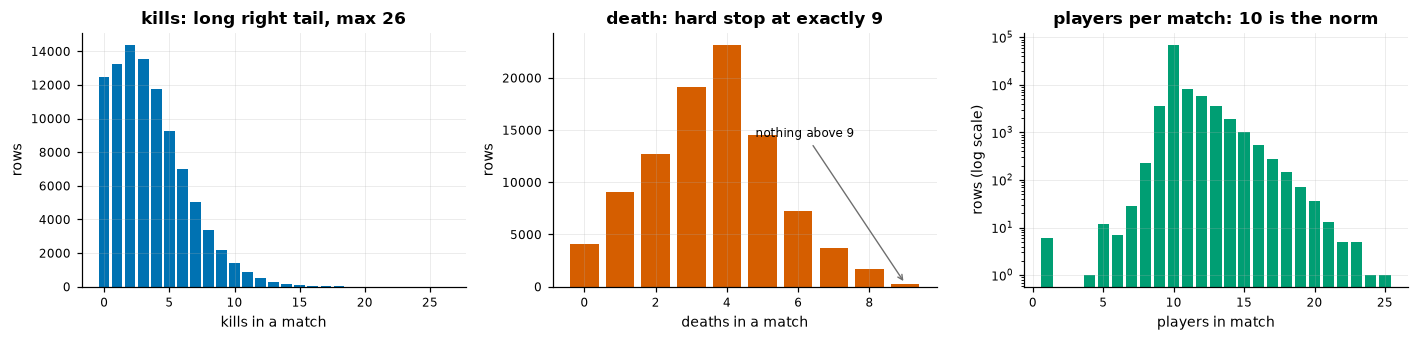

In [62]:
fig, axes = plt.subplots(1, 3, figsize=(13, 3.2))

k_counts = df["kills"].value_counts().sort_index()
axes[0].bar(k_counts.index, k_counts.values, color=BLUE, width=0.8)
axes[0].set(title="kills: long right tail, max 26", xlabel="kills in a match", ylabel="rows")

d_counts = df["death"].value_counts().sort_index()
axes[1].bar(d_counts.index, d_counts.values, color=VERMILLION, width=0.8)
axes[1].set(title="death: hard stop at exactly 9", xlabel="deaths in a match", ylabel="rows")
axes[1].annotate("nothing above 9", xy=(d_counts.index[-1], d_counts.iloc[-1]),
                 xytext=(4.8, d_counts.max() * 0.62), fontsize=8,
                 arrowprops=dict(arrowstyle="->", color=GREY, linewidth=0.9))

p_counts = df["playernb_in_match"].value_counts().sort_index()
axes[2].bar(p_counts.index, p_counts.values, color=GREEN, width=0.8)
axes[2].set_yscale("log")
axes[2].set(title="players per match: 10 is the norm", xlabel="players in match",
            ylabel="rows (log scale)")

fig.tight_layout()
plt.show()

**`kills` runs up to 26, but `death`
stops dead at exactly 9** which is completly normal as a game is at max 9 rounds and players can only die once per round (should wait for the next round to respawn)

Two implausibilities:

- **`playernb_in_match == 1` in a `PVP_UNRANKED` match** (1 row) —> a solo PvP match cannot happen in game.
  The 5 `OPERATIONS` rows with 1 player are fine; PvE is playable solo.
- **`playernb_in_match` up to 25** in a mode whose norm is 10. Same explanation as the team-balance
  finding: cumulative participants, not simultaneous ones.

### 2.6 Timeliness and timestamp sanity

Last check: are the timestamps orderable and physically possible? Specifically, does any player have
two matches so close together that they'd have to be playing both at once?

In [63]:
chrono = df.sort_values(["playerid", "match_ts"])
gap_seconds = chrono.groupby("playerid")["match_ts"].diff().dt.total_seconds()

print(f"consecutive-match gaps measured : {gap_seconds.notna().sum():,}")
print(f"gaps of exactly 0 s (impossible): {(gap_seconds == 0).sum()}")
print(f"gaps under 60 s (implausible)   : {(gap_seconds < 60).sum()}")
print(f"gaps under 5 min                : {(gap_seconds < 300).sum()}")
print("\ngap quantiles, in minutes:")
print((gap_seconds.quantile([0.05, 0.25, 0.5, 0.75, 0.95]) / 60).round(1).to_frame("minutes").to_string())

consecutive-match gaps measured : 94,894
gaps of exactly 0 s (impossible): 8
gaps under 60 s (implausible)   : 43
gaps under 5 min                : 1558

gap quantiles, in minutes:
      minutes
0.05     10.6
0.25     20.1
0.50     29.2
0.75    193.7
0.95   3922.7


The median gap between a player's consecutive matches is ~29 minutes, a believable match plus queue
cycle, and the quartiles look like real play sessions. Against that, **8 pairs share an identical
timestamp** and 43 are under a minute apart, but that can have some logical reasons like:

- Disconnections: Players leave a match and quickly join another.
- One match logged twice under different `matchid`s
- Duplicated events

43 out of 94,894
is negligible for aggregates, so I leave them in and note them.

### 2.7 Data-quality summary and the decisions I took

| # | Finding | Severity | Decision |
|---|---|---|---|
| 1 | `victory` has 4 values (`draw` 43, `other` 13), not 2 | **High**  | Exclude from the win-rate denominator; they break streaks |
| 2 | 24% of matches have unbalanced teams (up to 8-v-5) | Low | Flag; can happen because of commulation|
| 3 | 1 of 11 verifiable shared matches has contradictory outcomes | Medium | Flag; true rate at scale unknown |
| 4 | `kills` + `death` missing together on 153 rows (0.16%) | Low | Exclude from K/D aggregation; **do not** fill with 0 |
| 5 | 8 zero-second / 43 sub-minute gaps between a player's matches | Low | Keep; note as probable duplicate events |
| 6 | 1 `PVP_UNRANKED` match with `playernb_in_match = 1`, and 5 PvP matches with no opponents | Low | Flag as impossible match states |
| 7 | `match_datetime` is per-player, not per-match (0.3–366 s apart) | Low | Only ever order *within* a player |
| 8 | `playernb_in_match` up to 25 in a 10-player mode | Low | Flag; likely cumulative participants |

Nothing here justifies dropping rows wholesale.

---
## 3. Win/loss and K/D distributions

Before aggregating anything, I had to settle two small but important questions: should a draw count
as a loss, and what is the fairest way to calculate a player's K/D?

For win metrics I use decided matches only (`true` or `false`). I exclude `draw` and `other` rather
than quietly turning them into defeats. For K/D, I divide each player's total kills by total deaths.
I do not average match-level ratios, because a 5-kill/1-death match would receive much more weight
than a 5-kill/5-death match, and zero-death matches make the ratio undefined.

These choices are simple, but they determine what the distributions actually mean, so I apply them
consistently in the feature table later.

In [64]:
outcomes = df.groupby("playerid").agg(
    n_matches=("matchid", "size"),
    n_decided=("is_win", "count"),
    n_wins=("is_win", "sum"),
)
outcomes["n_wins"] = outcomes["n_wins"].astype(int)
outcomes["n_losses"] = (outcomes["n_decided"] - outcomes["n_wins"]).astype(int)
outcomes["win_rate"] = outcomes["n_wins"] / outcomes["n_decided"]
outcomes["win_loss_ratio"] = outcomes["n_wins"] / outcomes["n_losses"].replace(0, np.nan)

combat = df.groupby("playerid").agg(
    n_stat_matches=("kills", "count"),
    total_kills=("kills", "sum"),
    total_deaths=("death", "sum"),
    avg_kills=("kills", "mean"),
    avg_deaths=("death", "mean"),
)
combat["kd_ratio"] = combat["total_kills"] / combat["total_deaths"].replace(0, np.nan)

player_performance = outcomes.join(combat)
print(f"players with no losses (W/L undefined): {(outcomes['n_losses'] == 0).sum()}")
print(f"players with no deaths (K/D undefined): {(combat['total_deaths'] == 0).sum()}\n")
player_performance[["n_wins", "n_losses", "win_rate", "win_loss_ratio", "kd_ratio"]].describe(
    percentiles=[0.05, 0.25, 0.5, 0.75, 0.95]
).round(3)

players with no losses (W/L undefined): 48
players with no deaths (K/D undefined): 7



,n_wins,n_losses,win_rate,win_loss_ratio,kd_ratio
count,840.000,840.000,840.000,792.000,833.000
mean,54.663,59.239,0.463,0.975,0.898
std,103.242,112.726,0.228,0.853,0.588
min,0.000,0.000,0.000,0.000,0.000
5%,0.000,0.000,0.000,0.000,0.000
25%,2.000,2.000,0.391,0.618,0.524
50%,14.000,13.000,0.489,0.922,0.863
75%,53.250,60.000,0.549,1.145,1.171
95%,257.350,290.300,1.000,2.169,1.805
max,989.000,985.000,1.000,13.000,5.000


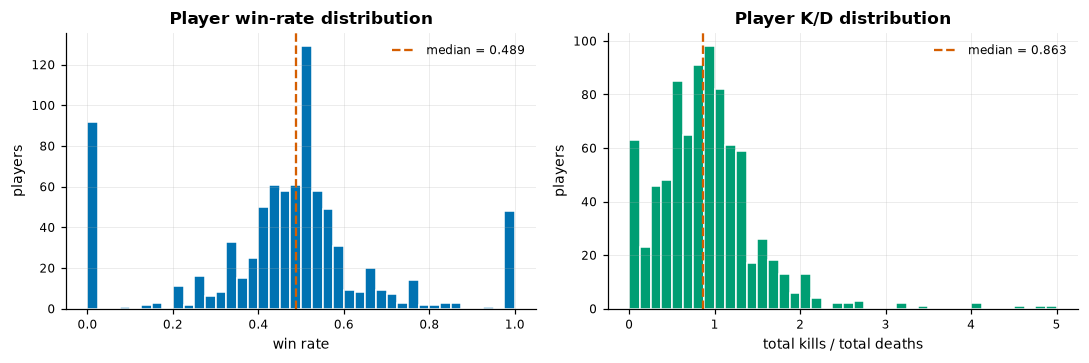

In [65]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3.4))

axes[0].hist(outcomes["win_rate"], bins=40, color=BLUE, edgecolor="white")
axes[0].axvline(outcomes["win_rate"].median(), color=VERMILLION, linestyle="--",
                label=f"median = {outcomes['win_rate'].median():.3f}")
axes[0].set(title="Player win-rate distribution", xlabel="win rate", ylabel="players")
axes[0].legend()

axes[1].hist(combat["kd_ratio"].dropna(), bins=40, color=GREEN, edgecolor="white")
axes[1].axvline(combat["kd_ratio"].median(), color=VERMILLION, linestyle="--",
                label=f"median = {combat['kd_ratio'].median():.3f}")
axes[1].set(title="Player K/D distribution", xlabel="total kills / total deaths", ylabel="players")
axes[1].legend()

fig.tight_layout()
plt.show()

Across the 840 players, the median win rate is **0.489** (IQR 0.391–0.549). What stands out to me is
how close the centre is to 50%, while the spikes at 0 and 1 mostly come from players with very few
matches. I would therefore be careful about reading an extreme win rate as skill without also looking
at match volume.

Median K/D is **0.863** (IQR 0.524–1.171), with a longer upper tail. That tail needs a caveat: Section
2 showed that recorded deaths stop at 9, so the strongest K/D values may be inflated.

There are 48 players with no losses and seven with no recorded deaths. Their W/L or K/D ratio is left
undefined rather than forcing a misleading finite value.

---
## 4. Longest victory and defeat streaks (players with at least 3 matches)

A streak sounds straightforward until the data contains draws, `other` outcomes and several game
modes. I define it as consecutive results in chronological order within a player: a draw or `other`
breaks the sequence without counting as either a victory or a defeat.

I keep matches from all modes because the question asks for each player's overall streak rather than
a mode-specific one. After computing the streaks, I apply the requested minimum of three matches.

In [66]:
outcome = chrono["victory"].map({"true": "W", "false": "L"}).fillna("X")
new_run = outcome.ne(outcome.shift()) | chrono["playerid"].ne(chrono["playerid"].shift())
run_id = new_run.cumsum()

runs = (pd.DataFrame({"playerid": chrono["playerid"], "outcome": outcome, "run_id": run_id})
        .groupby(["playerid", "outcome", "run_id"], sort=False)
        .size().rename("run_length").reset_index())

max_streaks = (runs.pivot_table(index="playerid", columns="outcome", values="run_length", aggfunc="max")
               .reindex(columns=["W", "L"])
               .rename(columns={"W": "max_victory_streak", "L": "max_defeat_streak"})
               .fillna(0).astype(int))

eligible = max_streaks.join(outcomes["n_matches"])
eligible = eligible[eligible["n_matches"] >= 3]
print(f"players with at least 3 matches: {len(eligible)}")
eligible[["max_victory_streak", "max_defeat_streak"]].describe(
    percentiles=[0.25, 0.5, 0.75, 0.95]
).round(2)

players with at least 3 matches: 700


,max_victory_streak,max_defeat_streak
count,700.00,700.00
mean,4.88,5.17
std,2.93,3.17
min,0.00,0.00
25%,3.00,3.00
50%,4.00,5.00
75%,7.00,7.00
95%,10.00,11.00
max,29.00,20.00


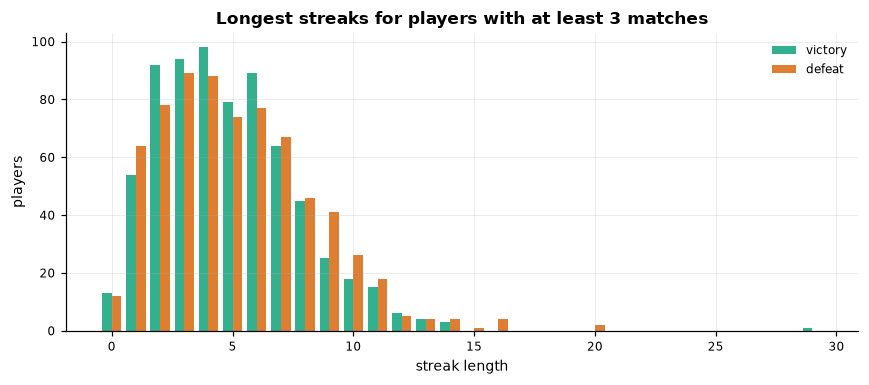

In [67]:
max_streak = int(eligible[["max_victory_streak", "max_defeat_streak"]].to_numpy().max())
bins = np.arange(-0.5, max_streak + 1.5)

fig, ax = plt.subplots(figsize=(8, 3.6))
ax.hist([eligible["max_victory_streak"], eligible["max_defeat_streak"]], bins=bins,
        color=[GREEN, VERMILLION], alpha=0.8, label=["victory", "defeat"])
ax.set(title="Longest streaks for players with at least 3 matches",
       xlabel="streak length", ylabel="players")
ax.legend()
fig.tight_layout()
plt.show()

The three-match rule leaves **700 of the 840 players**. Their median longest victory streak is **4**
and their median longest defeat streak is **5**; the observed maxima are 29 victories and 20 defeats.

The 29-win maximum caught my attention at first, but it belongs to a player with 1,342 matches. That
player had many more opportunities to produce a long run than someone with five or ten matches. I
therefore report the extremes, but I would not call them anomalies without considering match volume.

---
## 5. Player-level feature dataframe

The original file describes matches, but churn belongs to a player. I therefore aggregate to one row
per player before modelling.

I did not want to create every possible transformation simply because I could. I kept columns that
answer a clear behavioural question:

- **Activity:** how much and how regularly does the player play?
- **Performance:** how often do they win, and how do they perform in combat?
- **Streaks:** what are their longest victory and defeat runs?
- **Mode mix:** do they mainly play ranked, and how many modes do they use?

I left out UTC evening/weekend features because player locations are unknown, and I did not retain the
roster-based social features because they are difficult to separate from simple match volume. The
reference date for recency is the last timestamp in the extract, not today's date.

In [68]:
REFERENCE_DATE = df["match_ts"].max()

players = df.groupby("playerid").agg(
    first_match=("match_ts", "min"),
    last_match=("match_ts", "max"),
    n_active_days=("match_date", "nunique"),
    churned=("churned", "first"),
)
players["tenure_days"] = (players["last_match"] - players["first_match"]).dt.total_seconds() / 86400
players["days_since_last_match"] = (REFERENCE_DATE - players["last_match"]).dt.total_seconds() / 86400

players = players.join(outcomes).join(combat).join(max_streaks)
players["matches_per_active_day"] = players["n_matches"] / players["n_active_days"]
players["median_gap_days"] = (gap_seconds / 86400).groupby(chrono["playerid"]).median()
players["ranked_share"] = df["gamemode"].eq("PVP_RANKED").groupby(df["playerid"]).mean()
players["n_gamemodes"] = df.groupby("playerid")["gamemode"].nunique()

FEATURE_COLUMNS = [
    "churned", "first_match", "last_match",
    "n_matches", "n_active_days", "tenure_days", "days_since_last_match",
    "matches_per_active_day", "median_gap_days",
    "n_wins", "n_losses", "win_rate", "win_loss_ratio",
    "avg_kills", "avg_deaths", "kd_ratio",
    "max_victory_streak", "max_defeat_streak",
    "ranked_share", "n_gamemodes",
]
players = players[FEATURE_COLUMNS]
players.to_csv(OUTPUT_DIR / "players_features.csv")
print(f"saved {OUTPUT_DIR / 'players_features.csv'} -> {players.shape[0]} players x {players.shape[1]} columns")

saved outputs/players_features.csv -> 840 players x 20 columns


In [69]:
print("missing values:")
print(players.isna().sum().loc[lambda s: s > 0].to_frame("missing").to_string(), "\n")
players.drop(columns=["first_match", "last_match"]).describe().T.round(3)

missing values:
                 missing
median_gap_days       92
win_loss_ratio        48
avg_kills              1
avg_deaths             1
kd_ratio               7 



,count,mean,std,min,25%,50%,75%,max
n_matches,840.0,113.969,214.270,1.000,5.000,27.500,111.250,1974.000
n_active_days,840.0,24.677,38.989,1.000,2.000,8.000,29.000,276.000
tenure_days,840.0,122.752,131.921,0.000,2.552,55.771,246.191,363.911
days_since_last_match,840.0,124.975,111.315,0.000,16.938,99.808,222.688,363.729
matches_per_active_day,840.0,3.555,2.155,1.000,2.000,3.311,4.596,14.075
median_gap_days,748.0,2.101,16.404,0.002,0.015,0.020,0.028,268.955
n_wins,840.0,54.663,103.242,0.000,2.000,14.000,53.250,989.000
n_losses,840.0,59.239,112.726,0.000,2.000,13.000,60.000,985.000
win_rate,840.0,0.463,0.228,0.000,0.391,0.489,0.549,1.000
win_loss_ratio,792.0,0.975,0.853,0.000,0.618,0.922,1.145,13.000


The exported dataframe contains **840 rows and 20 columns**. Those columns include the churn label and
two timestamps; they are not all predictive features. Section 6 selects 13 model inputs from this
table.

Most missing values have a clear structural explanation: a one-match player has no match gap, a
player with no losses has no W/L ratio, and a player with no deaths has no K/D. One case is different:
one player has missing combat statistics in every recorded match, so `avg_kills` and `avg_deaths` are
unobserved rather than structurally undefined. I leave all of these as missing instead of turning
missing telemetry into zero performance; imputation belongs inside the modelling pipeline.

`days_since_last_match` remains useful as a descriptive player feature and is kept in the exported
table, but Section 6 deliberately excludes it from the early-warning model because it sits too close
to the churn definition.

---
## 6. How I would approach churn prediction

### Start with the right unit

Churn is a player-level outcome, so I use the 840-row player dataframe from Section 5. I would not
split the original match table: that could put some matches from the same player in training and
others in testing, giving the model information about a player it is later asked to predict.

My first instinct was to use a temporal split. In a real churn project I would choose a date **T**,
build features from an observation window before T, and define churn from a later prediction window.
That is the cleanest way to reproduce how the model would be used.

I cannot do that here because `still_active` is a static flag and the dataset has no churn date. Also,
features such as `n_matches`, `n_active_days` and `tenure_days` currently use each player's complete
history. So I treat the following as a **proof-of-concept churn classification**, not as a reliable
estimate of future production performance.

For this exercise I use a stratified 80/20 player split: 672 players for training and model selection,
and 168 held out until the end. Within the training set I use stratified five-fold cross-validation,
which gives a more stable comparison than judging models from one small validation split.

A few guardrails stay non-negotiable:

- player IDs and raw dates are not model inputs;
- `days_since_last_match` is excluded because it is very close to the churn definition and would be
  too late to be useful for early intervention;
- missing values are imputed inside each pipeline, using training-fold information only;
- the target split is 58/42, so I do not use SMOTE or other synthetic resampling.

In [70]:
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, average_precision_score, roc_auc_score
from sklearn.model_selection import StratifiedKFold, cross_validate, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

MODEL_FEATURES = [
    "n_matches", "n_active_days", "tenure_days", "matches_per_active_day", "median_gap_days",
    "win_rate", "avg_kills", "avg_deaths", "kd_ratio",
    "max_victory_streak", "max_defeat_streak", "ranked_share", "n_gamemodes",
]
X = players[MODEL_FEATURES]
y = players["churned"].astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=42
)

pd.DataFrame({
    "players": [len(X_train), len(X_test)],
    "churn_rate": [y_train.mean(), y_test.mean()],
}, index=["training", "hold-out"]).round(3)

,players,churn_rate
training,672,0.580
hold-out,168,0.583


In [71]:
# I keep the comparison small: a baseline, a linear model and one nonlinear model.
models = {
    "majority baseline": Pipeline([
        ("impute", SimpleImputer(strategy="median")),
        ("model", DummyClassifier(strategy="most_frequent")),
    ]),
    "logistic regression": Pipeline([
        ("impute", SimpleImputer(strategy="median")),
        ("scale", StandardScaler()),
        ("model", LogisticRegression(max_iter=2000, random_state=42)),
    ]),
    "random forest": Pipeline([
        ("impute", SimpleImputer(strategy="median")),
        ("model", RandomForestClassifier(n_estimators=300, min_samples_leaf=3,
                                         random_state=42, n_jobs=-1)),
    ]),
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_rows = []
for name, model in models.items():
    scores = cross_validate(
        model, X_train, y_train, cv=cv,
        scoring={"roc_auc": "roc_auc", "pr_auc": "average_precision"},
        n_jobs=-1,
    )
    cv_rows.append({
        "model": name,
        "roc_auc_mean": scores["test_roc_auc"].mean(),
        "roc_auc_sd": scores["test_roc_auc"].std(),
        "pr_auc_mean": scores["test_pr_auc"].mean(),
    })

cv_results = pd.DataFrame(cv_rows).set_index("model")
cv_results.round(3)

,roc_auc_mean,roc_auc_sd,pr_auc_mean
model,,,
majority baseline,0.500,0.000,0.580
logistic regression,0.773,0.043,0.793
random forest,0.773,0.038,0.802


In [72]:
# Logistic regression and random forest are tied in CV, so I prefer the simpler model.
preferred_name = "logistic regression"
preferred_model = models[preferred_name]
preferred_model.fit(X_train, y_train)
probabilities = preferred_model.predict_proba(X_test)[:, 1]
predictions = preferred_model.predict(X_test)

pd.Series({
    "preferred_model": preferred_name,
    "test_roc_auc": roc_auc_score(y_test, probabilities),
    "test_pr_auc": average_precision_score(y_test, probabilities),
    "test_accuracy": accuracy_score(y_test, predictions),
}).to_frame("result")

,result
preferred_model,logistic regression
test_roc_auc,0.781122
test_pr_auc,0.790805
test_accuracy,0.732143


### Why these models?

I would rather understand three models properly than run ten algorithms and report whichever score is
largest.

- The **majority classifier** is the minimum bar.
- **Logistic regression** is my first real model: it is fast, stable on a small dataset and its
  coefficients can be discussed with a retention or product team.
- The **random forest** checks whether nonlinear thresholds and interactions add meaningful signal.
  For example, low activity might matter differently for a ranked-only player than for someone who
  uses several modes.

I expected the random forest to improve on the linear model, but it did not do so convincingly. Both
models reach **0.773 mean CV ROC-AUC**, with fold standard deviations around 0.04. A difference below
the displayed precision is not evidence that the forest is better, so I keep logistic regression as
my preferred model. It is the simpler explanation and the data gives me no reason to pay for extra
complexity.

On the untouched hold-out, logistic regression reaches **0.781 ROC-AUC**, **0.791 PR-AUC** and
**73.2% accuracy**. Those numbers show that the player features contain useful information, but I
would not present them as production churn performance: the features still describe complete player
histories and the label has no date.

The next step is therefore a data-design step, not a larger model. I would request a dated churn
definition, rebuild the features inside a fixed observation window, and validate on a later period.
Only after that would I tune a decision threshold using the cost of a missed churner versus an
unnecessary retention offer.